In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('Student_Performance.csv')

In [ ]:
df.head()

,student_id,age,gender,school_type,parent_education,study_hours,attendance_percentage,internet_access,travel_time,extra_activities,study_method,math_score,science_score,english_score,overall_score,final_grade
0,1,14,male,public,post graduate,3.1,84.3,yes,<15 min,yes,notes,42.7,55.4,57.0,53.1,e
1,2,18,female,public,graduate,3.7,87.8,yes,>60 min,no,textbook,57.6,68.8,64.8,61.3,d
2,3,17,female,private,post graduate,7.9,65.5,no,<15 min,no,notes,84.8,95.0,79.2,89.6,b
3,4,16,other,public,high school,1.1,58.1,no,15-30 min,no,notes,44.4,27.5,54.7,41.6,e
4,5,16,female,public,high school,1.3,61.0,yes,30-60 min,yes,group study,8.9,32.7,30.0,25.4,f


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             25000 non-null  int64  
 1   age                    25000 non-null  int64  
 2   gender                 25000 non-null  object 
 3   school_type            25000 non-null  object 
 4   parent_education       25000 non-null  object 
 5   study_hours            25000 non-null  float64
 6   attendance_percentage  25000 non-null  float64
 7   internet_access        25000 non-null  object 
 8   travel_time            25000 non-null  object 
 9   extra_activities       25000 non-null  object 
 10  study_method           25000 non-null  object 
 11  math_score             25000 non-null  float64
 12  science_score          25000 non-null  float64
 13  english_score          25000 non-null  float64
 14  overall_score          25000 non-null  float64
 15  fi

In [ ]:
df.describe()

,student_id,age,study_hours,attendance_percentage,math_score,science_score,english_score,overall_score
count,25000.00000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,7493.04380,16.482760,4.253224,75.084084,63.785944,63.745320,63.681948,64.006172
std,4323.56215,1.703895,2.167541,14.373171,20.875262,20.970529,20.792693,18.932025
min,1.00000,14.000000,0.500000,50.000000,0.000000,0.000000,0.000000,14.500000
25%,3743.75000,15.000000,2.400000,62.800000,48.300000,48.200000,48.300000,49.000000
50%,7461.50000,16.000000,4.300000,75.100000,64.100000,64.100000,64.200000,64.200000
75%,11252.00000,18.000000,6.100000,87.500000,80.000000,80.000000,80.000000,79.000000
max,15000.00000,19.000000,8.000000,100.000000,100.000000,100.000000,100.000000,100.000000


In [ ]:
df.shape

(25000, 16)

# **Exploratory** **Data** **Analysis**

In [ ]:
df.isnull().sum() # No missing value

,0
student_id,0
age,0
gender,0
school_type,0
parent_education,0
study_hours,0
attendance_percentage,0
internet_access,0
travel_time,0
extra_activities,0


In [ ]:
df.duplicated().sum() # 10000 duplicated rows. need to check

np.int64(10000)

In [ ]:
num_cols=['age','study_hours','attendance_percentage']
sub_score=['math_score','science_score','english_score','overall_score']
cat_cols=['gender','school_type','parent_education','internet_access','extra_activities','study_method','travel_time']

## **Analysis** **on** **continous** **variables** **via** **histogram**

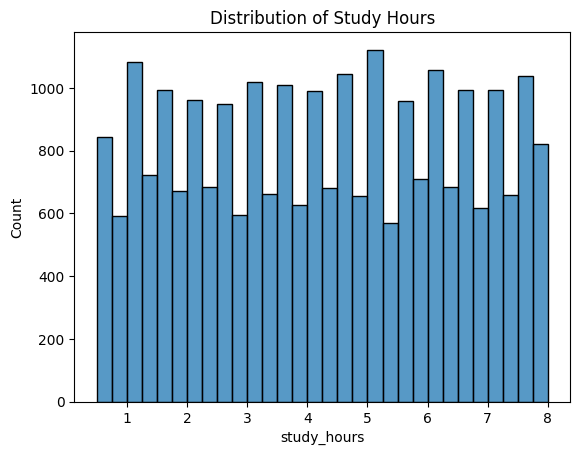

In [ ]:
sns.histplot(x=df['study_hours'])
plt.title("Distribution of Study Hours")
plt.show()

### EDA Conclusion — Numerical Distributions
- The numerical variables show variation across students, while study hours and attendance provide useful behavioral information.
- The distributions also help identify possible extreme values that should be checked before modeling.

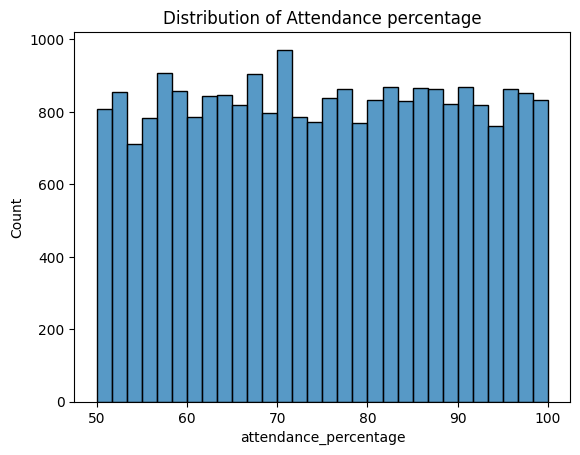

In [ ]:
sns.histplot(x=df['attendance_percentage'])
plt.title("Distribution of Attendance percentage")
plt.show()

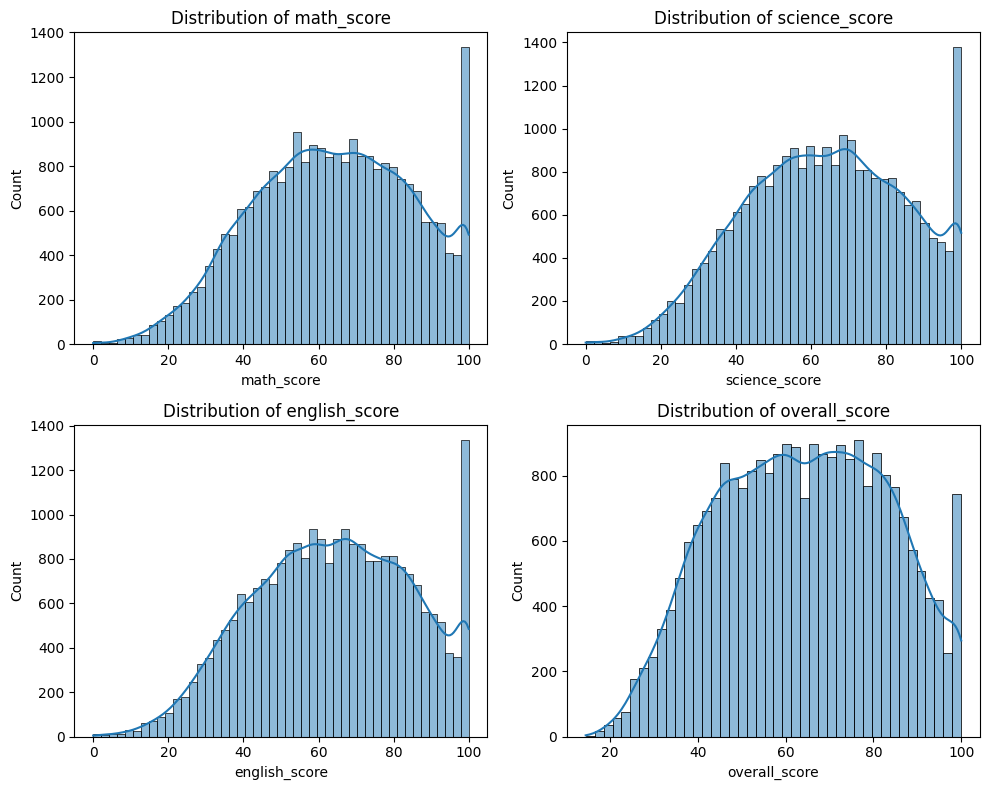

In [ ]:
plt.figure(figsize=(10,8))
for i,col in enumerate(sub_score,1):
  plt.subplot(2,2,i)
  sns.histplot(df[col],kde=True)
  plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()


## **Analysis** **of** **Categorical** **Variables** **via** **Count** **plot**

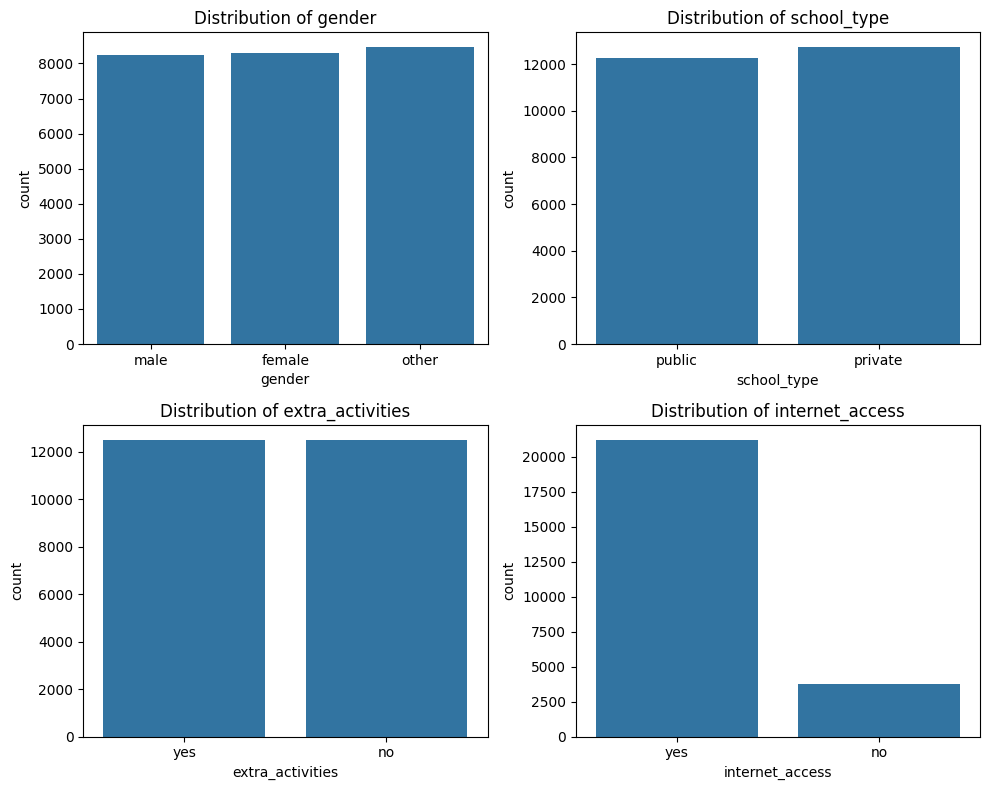

In [ ]:
plt.figure(figsize=(10,8))
for i,col in enumerate(['gender','school_type','extra_activities','internet_access'],1):
  plt.subplot(2,2,i)
  sns.countplot(x=df[col])
  plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

### EDA Conclusion — Categorical Variables
- The categorical variables contain multiple student groups suitable for categorical encoding.
- The distributions provide an overview of the composition of the dataset before modeling.

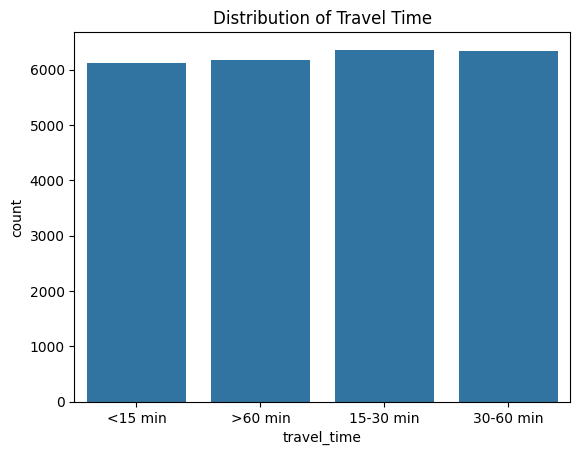

In [ ]:
sns.countplot(x=df['travel_time'])
plt.title("Distribution of Travel Time")
plt.show()

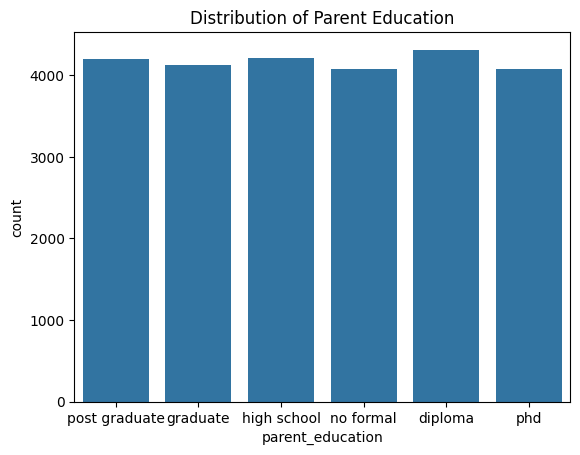

In [ ]:
sns.countplot(x=df['parent_education'])
plt.title("Distribution of Parent Education")
plt.show()

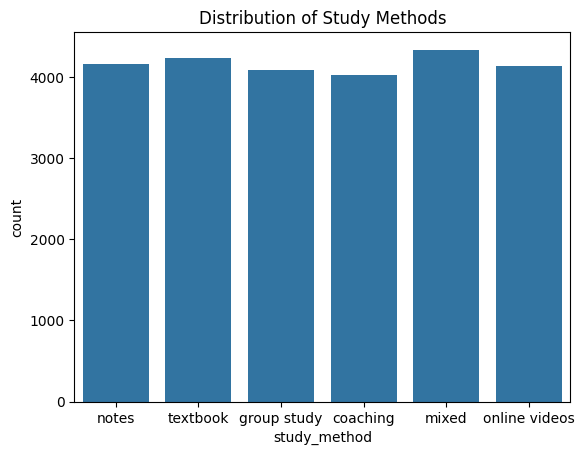

In [ ]:
sns.countplot(x=df['study_method'])
plt.title("Distribution of Study Methods")
plt.show()

## **Checking Outliers Via BoxPlot**

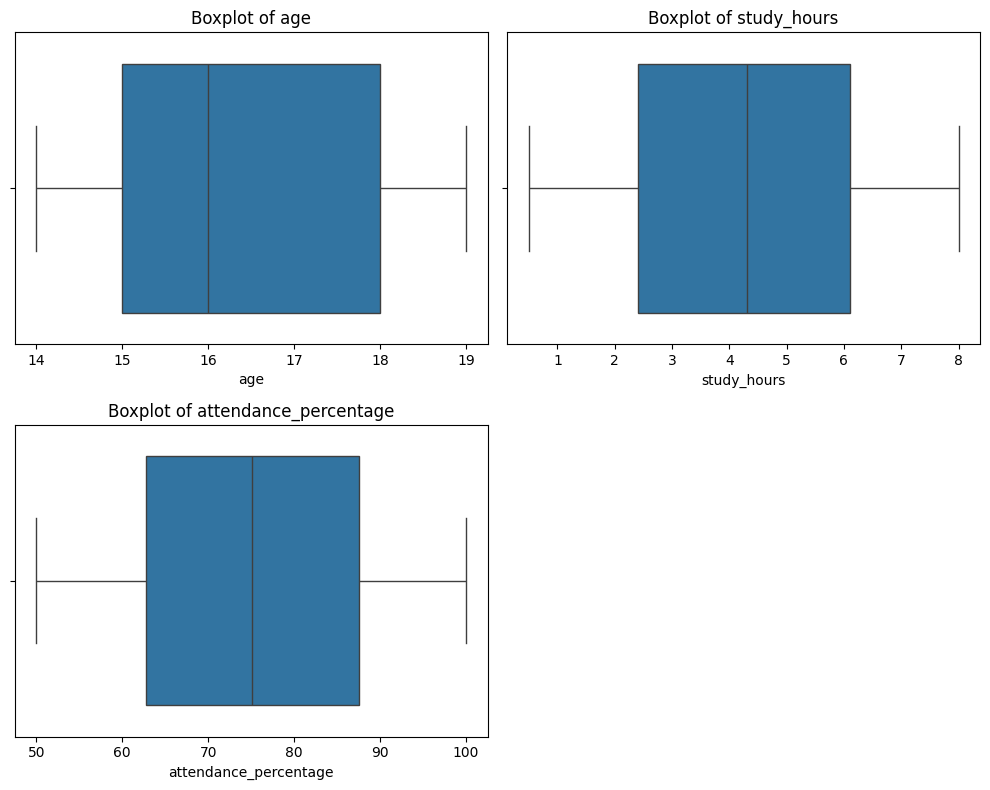

In [ ]:
plt.figure(figsize=(10,8))
for i,col in enumerate(num_cols,1):
  plt.subplot(2,2,i)
  sns.boxplot(x=df[col])
  plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

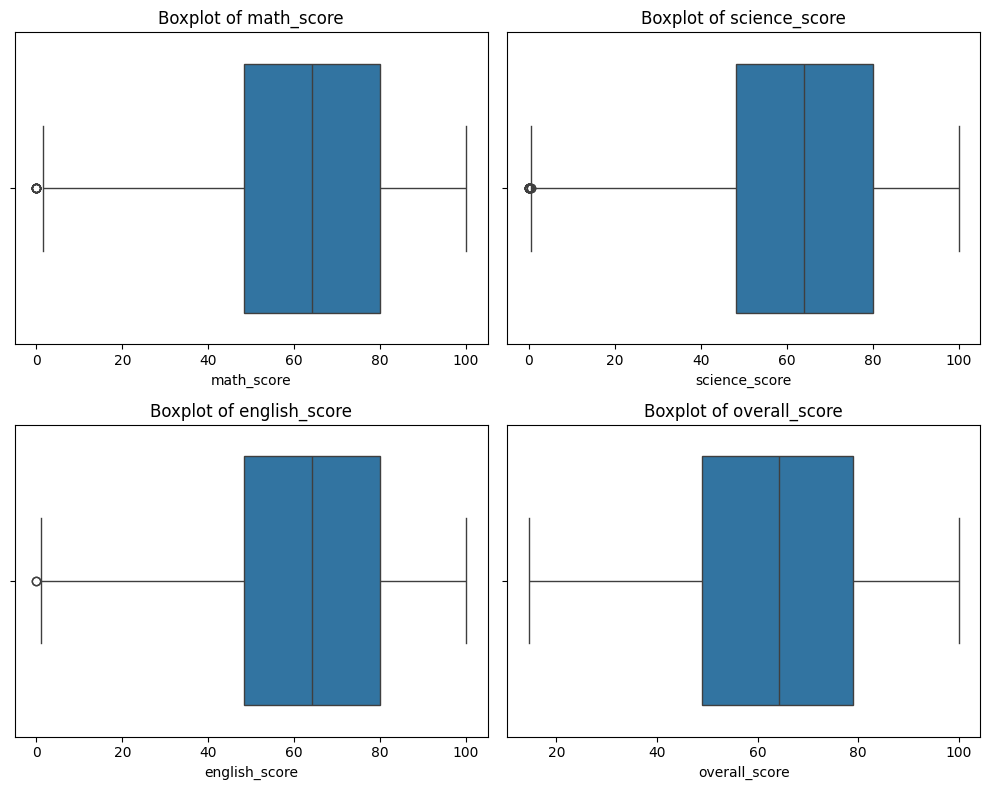

In [ ]:
plt.figure(figsize=(10,8))
for i,col in enumerate(sub_score,1):
  plt.subplot(2,2,i)
  sns.boxplot(x=df[col])
  plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

In [ ]:
for sub in ['math_score','science_score','english_score']:
  print((df[sub]==0).sum())

10
10
2


## **Relation between Target Variable and Features**

### **Numerical Features- Region Plot**

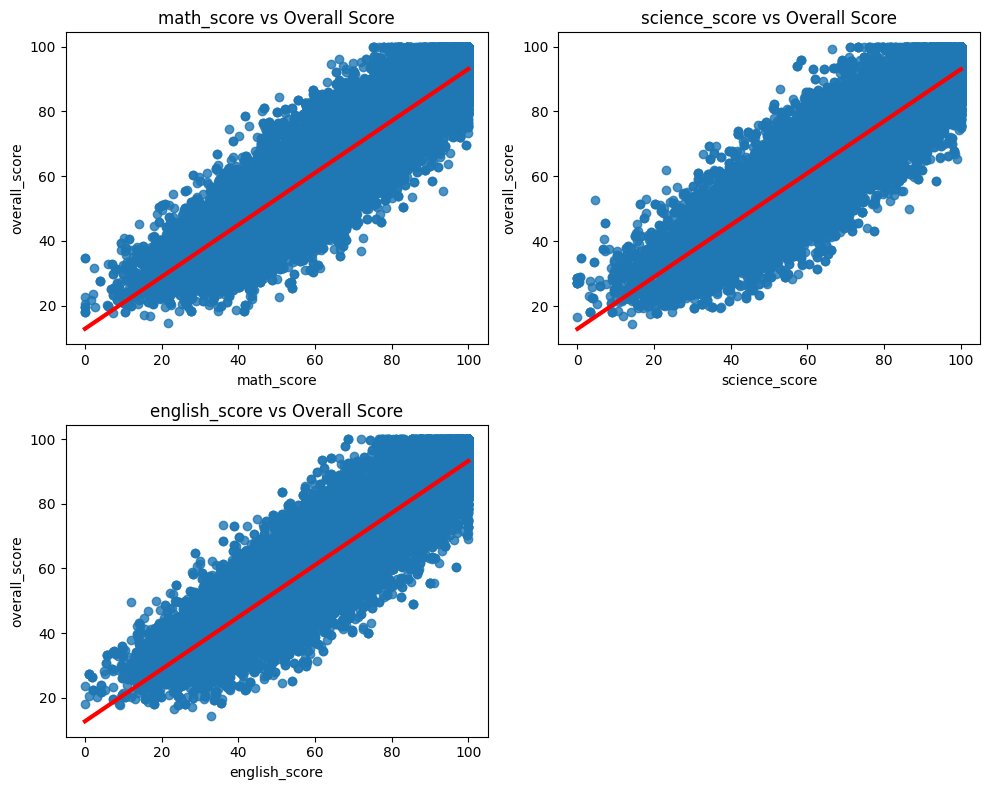

In [ ]:
plt.figure(figsize=(10,8))
for i,col in enumerate(['math_score','science_score','english_score'],1):
  plt.subplot(2,2,i)
  sns.regplot(x=df[col],y=df['overall_score'],line_kws={'color':'red','linewidth':3})
  plt.title(f"{col} vs Overall Score")
plt.tight_layout()
plt.show()

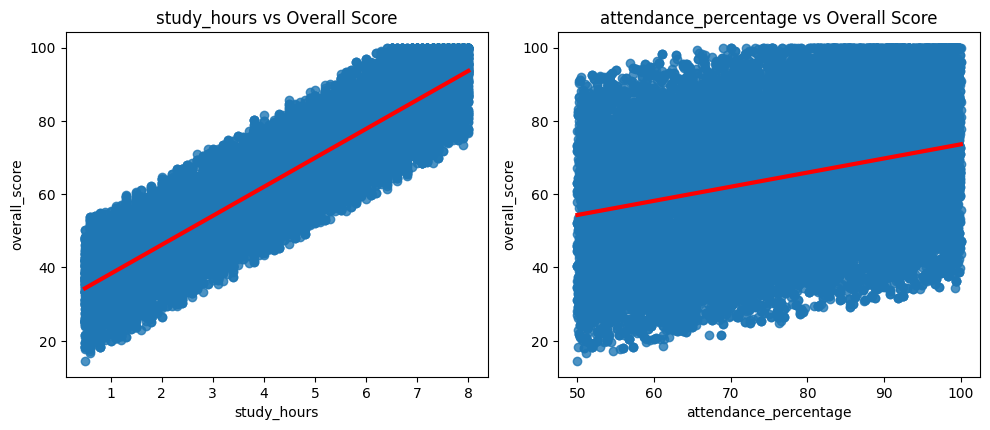

In [ ]:
plt.figure(figsize=(10,8))
for i,col in enumerate(['study_hours','attendance_percentage'],1):
  plt.subplot(2,2,i)
  sns.regplot(x=df[col],y=df['overall_score'],line_kws={'color':'red','linewidth':3})
  plt.title(f"{col} vs Overall Score")
plt.tight_layout()
plt.show()

### **Categorical Features - Box plot**

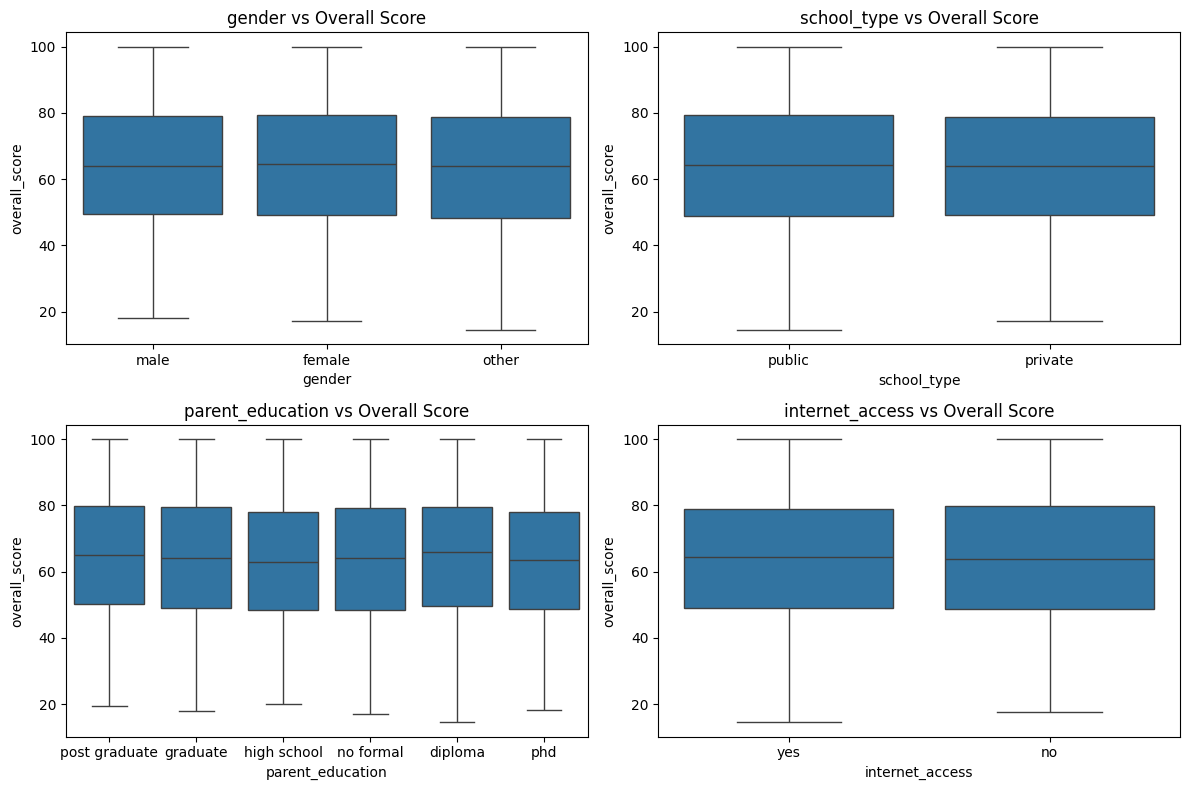

In [ ]:
plt.figure(figsize=(12,8))
for i,col in enumerate(['gender','school_type','parent_education','internet_access'],1):
  plt.subplot(2,2,i)
  sns.boxplot(x=df[col],y=df['overall_score'])
  plt.title(f"{col} vs Overall Score")
plt.tight_layout()
plt.show()

### EDA Conclusion — Outlier Analysis
- Box plots were used to identify unusually high or low observations in numerical variables.
- Any extreme observations should be interpreted carefully because they may affect model training and evaluation.

### EDA Conclusion — Categorical vs Overall Score
- The categorical groups show differences in overall-score distributions, although their effects are generally weaker than the strongest numerical relationships.
- These variables are retained as categorical inputs and encoded during preprocessing.

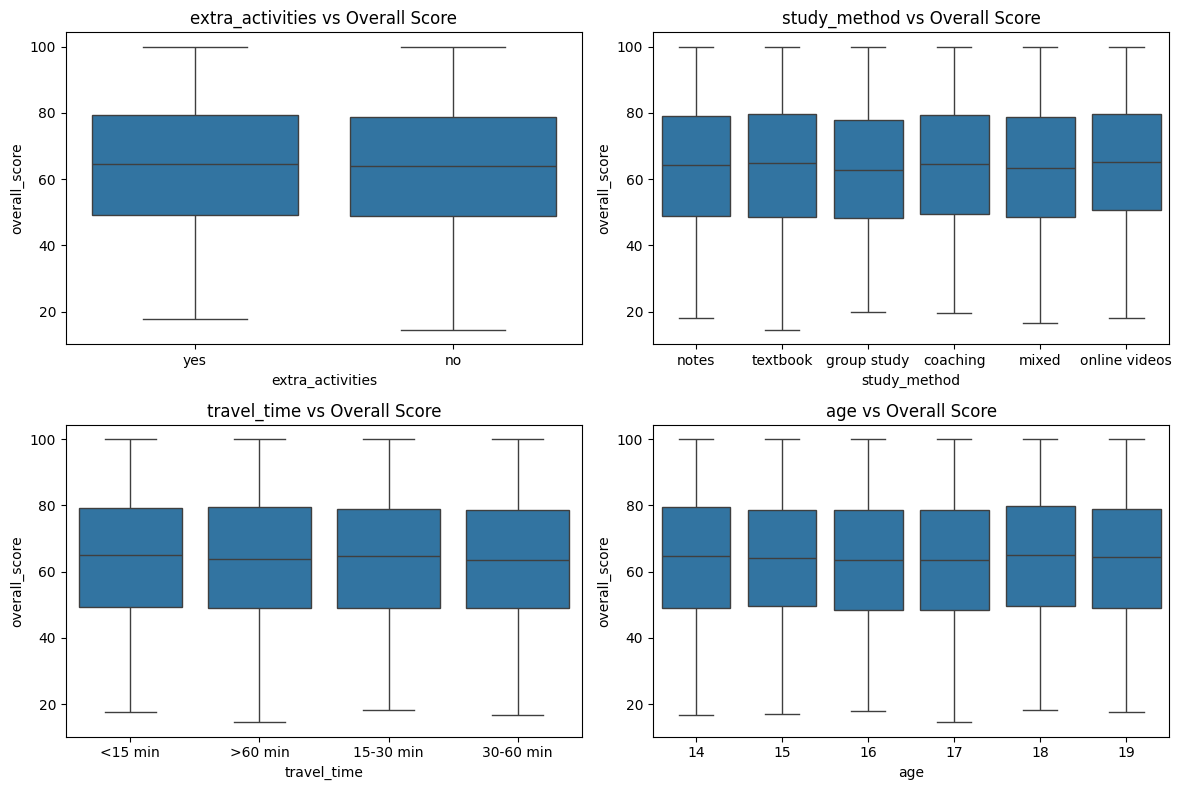

In [ ]:
plt.figure(figsize=(12,8))
for i,col in enumerate(['extra_activities','study_method','travel_time','age'],1):
  plt.subplot(2,2,i)
  sns.boxplot(x=df[col],y=df['overall_score'])
  plt.title(f"{col} vs Overall Score")
plt.tight_layout()
plt.show()

### **Correlation heatmap**

### EDA Conclusion — Correlation Analysis
- Study hours have the strongest reported correlation with overall score (approximately 0.91).
- Attendance has a weaker positive correlation (approximately 0.29), while age has almost no linear correlation (approximately -0.004).
- Subject scores are strongly correlated with overall score and with one another; however, they are excluded from the deployed prediction features.

<Axes: >

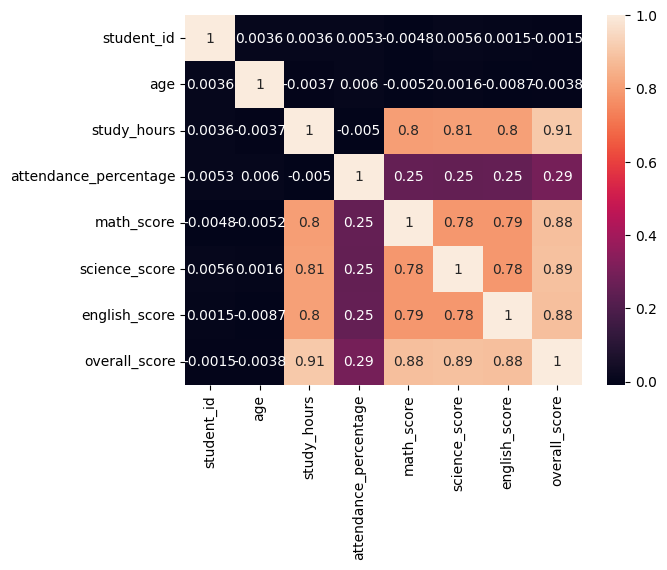

In [ ]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

# **DATA PREPROCESSING AND CLEANING**

**from this correlation heatmap we can conclude that study_hours is the most important feature as it has a correlation of 0.91 with overall_score whereas student_id has the least. also age has very low correlation with overall_score.**

In [ ]:
X=df.drop(columns=['math_score','science_score','english_score','overall_score','student_id','final_grade',])
X

,age,gender,school_type,parent_education,study_hours,attendance_percentage,internet_access,travel_time,extra_activities,study_method
0,14,male,public,post graduate,3.1,84.3,yes,<15 min,yes,notes
1,18,female,public,graduate,3.7,87.8,yes,>60 min,no,textbook
2,17,female,private,post graduate,7.9,65.5,no,<15 min,no,notes
3,16,other,public,high school,1.1,58.1,no,15-30 min,no,notes
4,16,female,public,high school,1.3,61.0,yes,30-60 min,yes,group study
...,...,...,...,...,...,...,...,...,...,...
24995,17,female,public,phd,1.8,55.2,yes,15-30 min,no,mixed
24996,16,female,private,diploma,2.7,97.1,yes,<15 min,no,coaching
24997,19,other,private,post graduate,1.0,63.0,yes,<15 min,no,group study
24998,14,male,private,diploma,1.0,69.4,yes,15-30 min,yes,group study


In [ ]:
y=df['overall_score']
y

,overall_score
0,53.1
1,61.3
2,89.6
3,41.6
4,25.4
...,...
24995,46.1
24996,56.5
24997,36.7
24998,34.1


In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,StandardScaler
ohe=OneHotEncoder(drop='first')
scaler=StandardScaler()
num_cols = ['age','study_hours','attendance_percentage']
cat_cols=['gender','school_type','parent_education','internet_access','extra_activities','study_method','travel_time']
preprocessor=ColumnTransformer(transformers=[('tf1',ohe,cat_cols),('tf2',scaler,num_cols)])


In [ ]:
preprocessor

ColumnTransformer(transformers=[('tf1', OneHotEncoder(drop='first'),
                                 ['gender', 'school_type', 'parent_education',
                                  'internet_access', 'extra_activities',
                                  'study_method', 'travel_time']),
                                ('tf2', StandardScaler(),
                                 ['age', 'study_hours',
                                  'attendance_percentage'])])

In [ ]:
X_train_transformed=preprocessor.fit_transform(X_train)
X_train_transformed.shape

(20000, 21)

In [ ]:
# Visualising X_train data
feature = preprocessor.get_feature_names_out()
X_train_transformed_df=pd.DataFrame(X_train_transformed,columns=feature)
X_train_transformed_df

,tf1__gender_male,tf1__gender_other,tf1__school_type_public,tf1__parent_education_graduate,tf1__parent_education_high school,tf1__parent_education_no formal,tf1__parent_education_phd,tf1__parent_education_post graduate,tf1__internet_access_yes,tf1__extra_activities_yes,...,tf1__study_method_mixed,tf1__study_method_notes,tf1__study_method_online videos,tf1__study_method_textbook,tf1__travel_time_30-60 min,tf1__travel_time_<15 min,tf1__travel_time_>60 min,tf2__age,tf2__study_hours,tf2__attendance_percentage
0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,-1.460208,1.127096,-1.114126
1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.477009,-1.456447,-1.330230
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,-1.460208,0.250537,1.026003
3,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.477009,0.204402,1.193310
4,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.872765,0.711884,-1.567248
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.302122,-0.026271,1.339703
19996,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,-0.872765,-1.087369,-0.884079
19997,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.477009,-1.594851,1.618547
19998,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,-0.285321,1.265500,-1.002588


In [ ]:
X_test_transformed=preprocessor.transform(X_test)
X_train_transformed.shape

(20000, 21)

In [ ]:
#Visualising X_test data
feature = preprocessor.get_feature_names_out()
X_train_transformed_df=pd.DataFrame(X_train_transformed,columns=feature)
X_train_transformed_df

,tf1__gender_male,tf1__gender_other,tf1__school_type_public,tf1__parent_education_graduate,tf1__parent_education_high school,tf1__parent_education_no formal,tf1__parent_education_phd,tf1__parent_education_post graduate,tf1__internet_access_yes,tf1__extra_activities_yes,...,tf1__study_method_mixed,tf1__study_method_notes,tf1__study_method_online videos,tf1__study_method_textbook,tf1__travel_time_30-60 min,tf1__travel_time_<15 min,tf1__travel_time_>60 min,tf2__age,tf2__study_hours,tf2__attendance_percentage
0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,-1.460208,1.127096,-1.114126
1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.477009,-1.456447,-1.330230
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,-1.460208,0.250537,1.026003
3,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.477009,0.204402,1.193310
4,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.872765,0.711884,-1.567248
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.302122,-0.026271,1.339703
19996,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,-0.872765,-1.087369,-0.884079
19997,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.477009,-1.594851,1.618547
19998,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,-0.285321,1.265500,-1.002588


# **MODEL SELECTION AND TRAINING**

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [ ]:
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )
}

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

results = []

for name, model in models.items():

    # Train the model
    model.fit(X_train_transformed, y_train)

    # Make predictions
    y_pred = model.predict(X_test_transformed)

    # Calculate evaluation metrics
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    # Store results
    results.append({
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R2 Score': r2
    })

results_df = pd.DataFrame(results)
results_df

,Model,MAE,RMSE,R2 Score
0,Linear Regression,5.008119,5.778343,0.908037
1,Decision Tree,3.341040,5.818052,0.906768
2,Random Forest,3.346107,4.548450,0.943018


**As we can see from the above models, the random forest gives us the highest accuracy **

In [ ]:
rf_model = models['Random Forest']

y_pred_rf = rf_model.predict(X_test_transformed)

# **CLASSSIFICATION MODEL**

In [ ]:
def performance_category(score):
    if score >= 80:
        return 'High'
    elif score >= 50:
        return 'Average'
    else:
        return 'Low'
df['performance_category'] = df['overall_score'].apply(performance_category)

In [ ]:
df['performance_category'].value_counts()

,count
performance_category,
Average,12491
Low,6611
High,5898


In [ ]:
X_class = df.drop(columns=['math_score','science_score','english_score','overall_score','student_id','final_grade','performance_category'])
y_class = df['performance_category']

In [ ]:
from sklearn.model_selection import train_test_split

X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(X_class,y_class,test_size=0.2,random_state=42,stratify=y_class)

In [ ]:
X_train_class

,age,gender,school_type,parent_education,study_hours,attendance_percentage,internet_access,travel_time,extra_activities,study_method
20053,15,female,private,no formal,7.6,97.7,yes,30-60 min,no,coaching
12975,17,other,private,no formal,6.5,88.0,yes,30-60 min,yes,online videos
22431,15,other,private,diploma,1.4,73.8,yes,15-30 min,yes,online videos
24865,14,other,public,no formal,2.8,72.2,yes,15-30 min,yes,mixed
10011,16,male,public,phd,4.6,95.9,no,>60 min,no,textbook
...,...,...,...,...,...,...,...,...,...,...
19281,14,male,public,post graduate,4.1,70.3,yes,<15 min,no,textbook
2071,17,male,private,post graduate,6.7,76.4,yes,15-30 min,no,mixed
3612,17,female,public,diploma,5.5,86.3,yes,>60 min,yes,mixed
9476,16,other,private,graduate,5.4,82.4,yes,<15 min,no,notes


In [ ]:
y_train_class

,performance_category
20053,High
12975,High
22431,Low
24865,Average
10011,Average
...,...
19281,Average
2071,High
3612,High
9476,Average


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

num_cols_class = ['age','study_hours','attendance_percentage']

cat_cols_class = ['gender','school_type','parent_education','internet_access','travel_time','extra_activities','study_method']
preprocessor_class = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols_class),
        ('num', StandardScaler(), num_cols_class)
    ]
)

In [ ]:
X_train_class_transformed = preprocessor_class.fit_transform(X_train_class)

X_test_class_transformed = preprocessor_class.transform(X_test_class)

# **Classification Model Training**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [ ]:
models_class = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    'Decision Tree': DecisionTreeClassifier(
        random_state=42
    ),

    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )
}

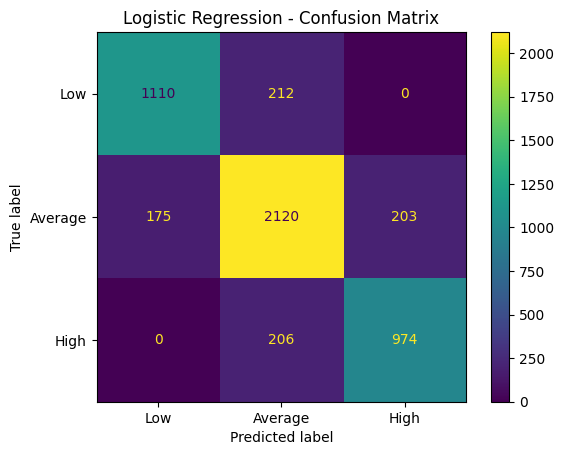

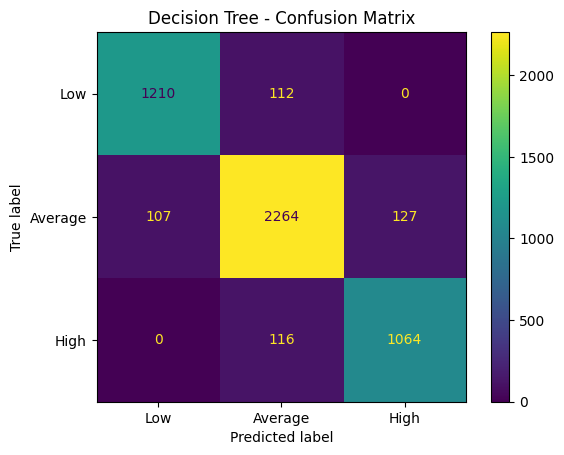

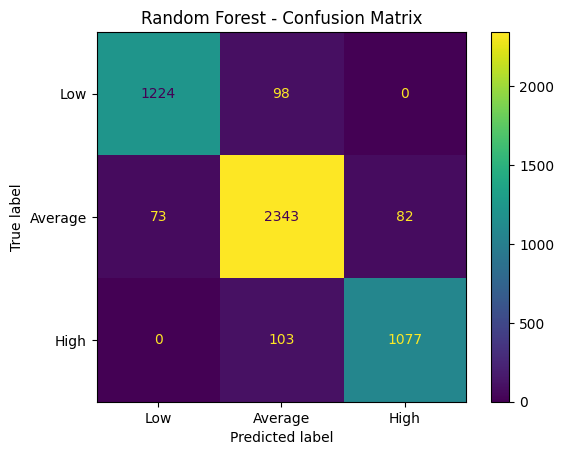

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.8408,0.841006,0.8408,0.840831
1,Decision Tree,0.9076,0.907644,0.9076,0.907616
2,Random Forest,0.9288,0.928948,0.9288,0.928795


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt
import pandas as pd

results_class = []

for name, model in models_class.items():

    # Train the model
    model.fit(X_train_class_transformed, y_train_class)

    # Make predictions
    y_pred_class = model.predict(X_test_class_transformed)

    # Evaluation metrics
    accuracy = accuracy_score(y_test_class, y_pred_class)

    precision = precision_score(
        y_test_class,
        y_pred_class,
        average='weighted'
    )

    recall = recall_score(
        y_test_class,
        y_pred_class,
        average='weighted'
    )

    f1 = f1_score(
        y_test_class,
        y_pred_class,
        average='weighted'
    )

    # Store results
    results_class.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1
    })

    # Confusion Matrix
    cm = confusion_matrix(
        y_test_class,
        y_pred_class,
        labels=['Low', 'Average', 'High']
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Low', 'Average', 'High']
    )

    disp.plot()
    plt.title(f'{name} - Confusion Matrix')
    plt.show()


# Results table
results_class_df = pd.DataFrame(results_class)
results_class_df

# **Recommendation** **System**

In [ ]:
def generate_recommendations(student, predicted_score, predicted_category):

    recommendations = []

    # 1. Study hours
    if student['study_hours'] < 3:
        recommendations.append(
            "Increase your daily study hours and maintain a consistent study routine."
        )

    # 2. Attendance
    if student['attendance_percentage'] < 75:
        recommendations.append(
            "Improve your attendance and try to maintain it above 75%."
        )

    # 3. Find weakest subject
    subjects = {
        'Mathematics': student['math_score'],
        'Science': student['science_score'],
        'English': student['english_score']
    }

    weakest_subject = min(subjects, key=subjects.get)
    weakest_score = subjects[weakest_subject]

    if weakest_score < 60:
        recommendations.append(
            f"Focus more on {weakest_subject}; your score is {weakest_score:.1f}."
        )

    # 4. Performance category
    if predicted_category == 'Low':
        recommendations.append(
            "Your predicted performance is Low. Attend additional practice sessions and increase your study consistency."
        )

    elif predicted_category == 'Average':
        recommendations.append(
            "Your predicted performance is Average. Increase your study effort and practice regularly to improve."
        )

    else:
        recommendations.append(
            "Your predicted performance is High. Maintain your current study routine and continue practicing."
        )

    return recommendations

In [ ]:
student = {
    'age': 18,
    'gender': 'Male',
    'school_type': 'Public',
    'parent_education': 'Graduate',
    'study_hours': 2,
    'attendance_percentage': 72,
    'internet_access': 'Yes',
    'travel_time': '15-30 min',
    'extra_activities': 'No',
    'study_method': 'textbook',

    'math_score': 45,
    'science_score': 72,
    'english_score': 65
}

In [ ]:
student = df.iloc[0].to_dict()

In [ ]:
predicted_score = 65
predicted_category = "Average"

In [ ]:
recommendations = generate_recommendations(
    student,
    predicted_score,
    predicted_category
)

for recommendation in recommendations:
    print("•", recommendation)

• Focus more on Mathematics; your score is 42.7.
• Your predicted performance is Average. Increase your study effort and practice regularly to improve.


In [ ]:
best_regression_model = models['Random Forest']
best_classification_model = models_class['Random Forest']

In [ ]:
def predict_student(student):

    # Features used by the ML models
    prediction_data = {
        'age': student['age'],
        'gender': student['gender'],
        'school_type': student['school_type'],
        'parent_education': student['parent_education'],
        'study_hours': student['study_hours'],
        'attendance_percentage': student['attendance_percentage'],
        'internet_access': student['internet_access'],
        'travel_time': student['travel_time'],
        'extra_activities': student['extra_activities'],
        'study_method': student['study_method']
    }

    student_df = pd.DataFrame([prediction_data])

    # Regression prediction
    student_reg_transformed = preprocessor.transform(student_df)

    predicted_score = best_regression_model.predict(
        student_reg_transformed
    )[0]

    # Classification prediction
    student_class_transformed = preprocessor_class.transform(student_df)

    predicted_category = best_classification_model.predict(
        student_class_transformed
    )[0]

    # Recommendations
    recommendations = generate_recommendations(
        student,
        predicted_score,
        predicted_category
    )

    return predicted_score, predicted_category, recommendations

In [ ]:
new_student = {
    'age': 18,
    'gender': 'male',
    'school_type': 'public',
    'parent_education': 'graduate',
    'study_hours': 2.5,
    'attendance_percentage': 72,
    'internet_access': 'yes',
    'travel_time': '15-30 min',
    'extra_activities': 'no',
    'study_method': 'textbook',

    'math_score': 45,
    'science_score': 68,
    'english_score': 74
}

In [ ]:
predicted_score, predicted_category, recommendations = predict_student(new_student)

In [ ]:
print("Predicted Overall Score:", round(predicted_score, 2))
print("Predicted Performance:", predicted_category)

print("\nRecommendations:")

for recommendation in recommendations:
    print("•", recommendation)

Predicted Overall Score: 49.43
Predicted Performance: Average

Recommendations:
• Increase your daily study hours and maintain a consistent study routine.
• Improve your attendance and try to maintain it above 75%.
• Focus more on Mathematics; your score is 45.0.
• Your predicted performance is Average. Increase your study effort and practice regularly to improve.


In [ ]:
import joblib

joblib.dump(best_regression_model, 'regression_model.pkl')
joblib.dump(best_classification_model, 'classification_model.pkl')
joblib.dump(preprocessor, 'preprocessor.pkl')
joblib.dump(preprocessor_class, 'preprocessor_class.pkl')

['preprocessor_class.pkl']

In [ ]:
!pip install -q streamlit

In [ ]:
!cat streamlit.log



2026-09-28 23:41:35.184 Uvicorn server started on :::8513

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8513
  Network URL: http://172.28.0.12:8513
  External URL: http://35.201.183.162:8513



In [ ]:
!lt --port 8501

your url is: https://thick-pigs-lay.loca.lt
^C


In [ ]:
!cp app.py Student_Performance.csv regression_model.pkl classification_model.pkl preprocessor.pkl preprocessor_class.pkl requirements.txt student-performance-prediction/

In [ ]:
import sys
import sklearn
import numpy
import pandas
import joblib

print("Python:", sys.version)
print("scikit-learn:", sklearn.__version__)
print("numpy:", numpy.__version__)
print("pandas:", pandas.__version__)
print("joblib:", joblib.__version__)

Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
scikit-learn: 1.6.1
numpy: 2.1.3
pandas: 2.2.3
joblib: 1.6.0


## Final Project Conclusion
The analysis shows that study habits and attendance provide useful information for predicting student performance. The final system combines regression for numerical score prediction, classification for performance categories, and rule-based recommendations in a Streamlit dashboard. Subject-score inputs are not used by the deployed prediction models, so the dashboard prediction is based on the student's profile, study habits, attendance, and related categorical features.